# 한국어 챗봇 만들기 프로젝트

이 프로젝트에서는 송영숙님이 공개한 `Chatbot_data`를 활용하여 트랜스포머(Transformer) 기반의 한국어 챗봇을 구현합니다.

## Step 1. 데이터 수집하기
한국어 챗봇 메인 데이터인 `ChatbotData.csv`를 다운로드하여 사용할 수 있도록 준비합니다.


In [2]:
# 필요한 라이브러리 임포트 및 버전 확인
import pandas as pd
import numpy as np
import os
import re
import urllib.request
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import sentencepiece as spm
import math
import matplotlib.pyplot as plt

print("모든 모듈이 정상적으로 임포트되었습니다.")


모든 모듈이 정상적으로 임포트되었습니다.


## Step 2. 데이터 전처리하기
영어 데이터용으로 작성된 기존 전처리 함수를 한국어(한글, 기본 알파벳, 숫자, 구두점)에 맞게 수정합니다. 구두점을 띄어쓰기로 분리하고 한글 등 필요한 문자 이외의 것은 공백으로 치환하는 방식으로 정제합니다. 


In [3]:
# 1. 데이터 불러오기 (다운로드 받은 경로 기준)
data_path = './data/ChatbotData.csv'
dataset = pd.read_csv(data_path)

print(f"전체 샘플 수: {len(dataset)}")
display(dataset.head())

# 2. 한국어에 맞춘 전처리 함수 정의
def preprocess_sentence(sentence):
    # 입력받은 sentence를 소문자로 변경하고 양쪽 공백을 제거
    sentence = sentence.lower().strip()

    # 단어와 구두점(punctuation) 사이의 거리를 만듭니다.
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)

    # 한글, 영문, 숫자, 기본 구두점(? . ! ,)을 제외한 문자를 공백으로 대체 (한국어 최적화)
    sentence = re.sub(r"[^가-힣ㄱ-ㅎㅏ-ㅣa-zA-Z0-9?.!,]+", " ", sentence)
    sentence = sentence.strip()
    
    return sentence

# 3. 질문(Q)과 답변(A) 전처리 수행
questions = [preprocess_sentence(q) for q in dataset['Q']]
answers = [preprocess_sentence(a) for a in dataset['A']]

# 4. 전처리 전후 결과 확인
print('\n[전처리 전 질문 샘플]:', dataset['Q'][0])
print('[전처리 후 질문 샘플]:', questions[0])
print('\n[전처리 전 답변 샘플]:', dataset['A'][0])
print('[전처리 후 답변 샘플]:', answers[0])


전체 샘플 수: 11823


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0



[전처리 전 질문 샘플]: 12시 땡!
[전처리 후 질문 샘플]: 12시 땡 !

[전처리 전 답변 샘플]: 하루가 또 가네요.
[전처리 후 답변 샘플]: 하루가 또 가네요 .


## Step 3. SentencePiece 사용하기
한국어는 형태소 분석기 없이도 서브워드 기반의 토크나이저인 SentencePiece(BPE) 모델이 매우 잘 동작합니다.
전처리된 한국어 질문과 답변 코퍼스 파일을 생성하고 이를 바탕으로 SentencePiece 모델을 학습시킵니다. 데이터셋 크기를 고려하여 `vocab_size`는 통상적인 8,000개에서 모델의 밀도를 높이기 위해 5,000개로 최적화합니다.


In [4]:
# 1. 텍스트 데이터를 하나의 텍스트 파일로 통합 (코퍼스 파일 생성)
corpus_file = "korean_chat_corpus.txt"
with open(corpus_file, 'w', encoding='utf-8') as f:
    for q, a in zip(questions, answers):
        f.write(q + "\n")
        f.write(a + "\n")

# 2. SentencePiece 모델 학습
VOCAB_SIZE = 5000  # 데이터 크기에 맞춰 적절히 축소
spm.SentencePieceTrainer.Train(
    input=corpus_file,
    model_prefix="spm_korean_chat",
    vocab_size=VOCAB_SIZE,
    character_coverage=0.9995,  # 한국어의 경우 다양한 문자가 많으므로 coverage를 조금 낮추어 잡음
    model_type="bpe",
    max_sentence_length=9999,
    bos_id=1,  # <s> 시작 토큰
    eos_id=2,  # </s> 종료 토큰
    pad_id=0,  # <pad> 패딩 토큰
    unk_id=3   # <unk> 언노운 토큰
)

# 3. 학습된 SentencePiece 모델 로드
sp = spm.SentencePieceProcessor()
sp.Load("spm_korean_chat.model")

print("Vocab size:", sp.GetPieceSize())


Vocab size: 5000


학습된 모델을 바탕으로 토크나이징을 진행하고, 입력 시퀀스와 타겟 시퀀스를 생성합니다. 이때 패딩을 추가해 모든 문장의 길이를 동일한 `MAX_LENGTH=40`으로 맞춘 PyTorch의 `Dataset` 및 `DataLoader`를 구성합니다.


In [5]:
MAX_LENGTH = 40

# DataLoader를 위한 한국어 챗봇 전용 Custom Dataset 클래스 정의
class KoreanChatDataset(Dataset):
    def __init__(self, questions, answers, sp, max_length=40):
        super().__init__()
        self.data = []

        bos_id = sp.bos_id()
        eos_id = sp.eos_id()

        for q_text, a_text in zip(questions, answers):
            # 토크나이즈 후 정수 인코딩
            q_ids = sp.EncodeAsIds(q_text)
            a_ids = sp.EncodeAsIds(a_text)

            # 시작 및 종료 토큰 추가
            q_tokens = [bos_id] + q_ids + [eos_id]
            a_tokens = [bos_id] + a_ids + [eos_id]

            # MAX_LENGTH보다 긴 문장은 제외 (또는 자르기)
            if len(q_tokens) > max_length or len(a_tokens) > max_length:
                continue

            # 고정 길이(MAX_LENGTH) 패딩 추가 -> <pad> = 0 가정
            q_tokens += [0] * (max_length - len(q_tokens))
            a_tokens += [0] * (max_length - len(a_tokens))

            # 디코더 입력(dec_input): 마지막 종료 토큰 직전까지
            # 디코더 타겟(target): 시작 토큰 제외한 나머지 길이 (Teacher Forcing)
            dec_input = a_tokens[:-1]
            target = a_tokens[1:]

            self.data.append({
                "enc_input": q_tokens,
                "dec_input": dec_input,
                "target": target
            })

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        return (torch.tensor(sample["enc_input"], dtype=torch.long),
                torch.tensor(sample["dec_input"], dtype=torch.long),
                torch.tensor(sample["target"], dtype=torch.long))

# 데이터셋 객체 생성
chat_dataset = KoreanChatDataset(questions, answers, sp, max_length=MAX_LENGTH)

# 배치 크기 설정 및 DataLoader 생성
BATCH_SIZE = 64
chat_dataloader = DataLoader(chat_dataset, batch_size=BATCH_SIZE, shuffle=True)

print("사용할 샘플 수:", len(chat_dataset))

# 첫 번째 배치 샘플 확인
for enc_in, dec_in, tgt in chat_dataloader:
    print("인코더 입력 텐서 크기 :", enc_in.size())
    print("디코더 입력 텐서 크기 :", dec_in.size())
    print("정답(타겟) 텐서 크기  :", tgt.size())
    break


사용할 샘플 수: 11823
인코더 입력 텐서 크기 : torch.Size([64, 40])
디코더 입력 텐서 크기 : torch.Size([64, 39])
정답(타겟) 텐서 크기  : torch.Size([64, 39])


## Step 4. 모델 구성하기

트랜스포머(Transformer) 아키텍처의 핵심 구성 요소를 구현합니다. 포지셔널 인코딩, 멀티-헤드 어텐션, 인코더 및 디코더 레이어를 차례로 구축하여 최종 모델을 완성합니다.
이후 데이터셋 크기(~1.1만 개)에 맞춰 과적합을 방지할 수 있도록 하이퍼파라미터(`NUM_LAYERS`, `D_MODEL` 등)를 코넬 데이터 대비 살짝 줄이거나 최적화하여 훈련을 준비합니다.


In [8]:
# ---------------------------------------------------------
# 1. 포지셔널 인코딩 (Positional Encoding)
# ---------------------------------------------------------
# 트랜스포머는 RNN과 달리 단어를 순차적으로 입력받지 않기 때문에,
# 단어의 '위치 정보'를 모델에 알려주기 위해 사인(Sin)과 코사인(Cos) 함수를 사용합니다.
class PositionalEncoding(nn.Module):
    def __init__(self, position, d_model):
        super(PositionalEncoding, self).__init__()
        self.d_model = d_model
        
        # position (최대 문장 길이) x d_model (임베딩 차원) 행렬 생성
        self.pos_encoding = self._build_pos_encoding(position, d_model)

    def _get_angles(self, position, i, d_model):
        # 각 차원마다 다른 주기(frequency)를 갖도록 각도(angle)를 계산합니다.
        return 1.0 / (10000.0 ** ((2.0 * (i // 2)) / d_model)) * position

    def _build_pos_encoding(self, position, d_model):
        pos = torch.arange(position, dtype=torch.float32).unsqueeze(1)
        i = torch.arange(d_model, dtype=torch.float32).unsqueeze(0)

        angle_rads = self._get_angles(pos, i, d_model)
        
        # 짝수 인덱스(2i)에는 사인 함수 적용
        sines = torch.sin(angle_rads[:, 0::2])
        # 홀수 인덱스(2i+1)에는 코사인 함수 적용
        cosines = torch.cos(angle_rads[:, 1::2])

        pos_encoding = torch.zeros(position, d_model)
        pos_encoding[:, 0::2] = sines
        pos_encoding[:, 1::2] = cosines

        # 배치 차원(batch_size)을 위해 차원 추가 : [1, position, d_model]
        pos_encoding = pos_encoding.unsqueeze(0) 
        return pos_encoding

    def forward(self, x):
        # 입력 임베딩 텐서(x)에 미리 계산된 포지셔널 인코딩 값을 단순히 더해줍니다.
        return x + self.pos_encoding[:, :x.size(1), :].to(x.device)

# ---------------------------------------------------------
# 2. 스케일드 닷 프로덕트 어텐션 (Scaled Dot-Product Attention)
# ---------------------------------------------------------
# 단어들 간의 '유사도'를 구하는 연산입니다. 마스크(Mask)가 주어지면 마스킹 처리도 동시에 수행합니다.
def scaled_dot_product_attention(query, key, value, mask=None):
    # 1) Q와 K의 Dot Product를 통해 어텐션 스코어 계산 (행렬 곱)
    matmul_qk = torch.matmul(query, key.transpose(-1, -2))

    # 2) 스케일링: 값의 발산을 막기 위해 임베딩 차원의 루트값으로 나눔
    depth = key.size(-1)
    logits = matmul_qk / math.sqrt(depth)

    # 3) 마스킹 적용: 패딩(Padding)이나 미래 단어(Look-ahead) 위치에는 아주 작은 값(-1e9)을 넣어 무시되도록 함
    if mask is not None:
        logits = logits + (mask * -1e9)

    # 4) Softmax: 단어들 간의 유사도 확률 분포 생성
    attention_weights = F.softmax(logits, dim=-1)

    # 5) Attention Weights와 Value 행렬을 곱해 최종 어텐션 값 추출
    output = torch.matmul(attention_weights, value)
    return output

# ---------------------------------------------------------
# 3. 멀티-헤드 어텐션 (Multi-Head Attention)
# ---------------------------------------------------------
# 여러 개의 어텐션(Head)을 병렬로 수행하여, 하나의 단어를 다양한 관점에서 학습하도록 합니다.
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        assert d_model % num_heads == 0 # d_model은 무조건 num_heads로 나누어 떨어져야 합니다.
        self.depth = d_model // num_heads # 각각의 헤드가 바라볼 임베딩 차원 (예: 256 / 8 = 32)

        # WQ, WK, WV 행렬을 학습하기 위한 연속된 선형 변환 레이어
        self.query_dense = nn.Linear(d_model, d_model)
        self.key_dense = nn.Linear(d_model, d_model)
        self.value_dense = nn.Linear(d_model, d_model)

        # 멀티 헤드 결과를 하나로 합친 뒤(Concat), 최종 변환하는 레이어
        self.out_dense = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        # (batch_size, seq_len, d_model) => (batch_size, num_heads, seq_len, depth) 구조로 텐서 변형
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3) 
        return x

    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)

        # Q, K, V 매트릭스에 선형 변환 적용
        query = self.query_dense(query)
        key = self.key_dense(key)
        value = self.value_dense(value)

        # 헤드 개수만큼 Q, K, V를 쪼개어(Split) 여러 개의 어텐션을 병렬 처리 준비
        query = self.split_heads(query, batch_size)
        key = self.split_heads(key, batch_size)
        value = self.split_heads(value, batch_size)

        # 어텐션 계산 수행
        scaled_attention = scaled_dot_product_attention(query, key, value, mask)

        # 떨어져 있던 헤드를 다시 하나로 모으기 위한 차원 변환
        scaled_attention = scaled_attention.permute(0, 2, 1, 3).contiguous()
        concat_attention = scaled_attention.view(batch_size, -1, self.d_model)

        # 최종 선형 변환
        output = self.out_dense(concat_attention)
        return output

# ---------------------------------------------------------
# 4. 마스크 생성 함수 (Padding Mask & Look-Ahead Mask)
# ---------------------------------------------------------
def create_padding_mask(x):
    # 문장 길이를 맞추기 위해 넣은 <pad> 토큰(0) 위치를 찾습니다.
    mask = (x == 0).float()
    # 어텐션 행렬 크기에 맞추기 위한 차원 확장
    return mask.unsqueeze(1).unsqueeze(2)

def create_look_ahead_mask(x):
    # 디코더에서 사용. 자기 자신보다 '미래'에 나타나는 단어를 참조할 수 없도록 마스킹 처리합니다.
    seq_len = x.size(1)
    look_ahead_mask = 1 - torch.tril(torch.ones((seq_len, seq_len)))
    padding_mask = create_padding_mask(x)
    
    look_ahead_mask = look_ahead_mask.unsqueeze(0).unsqueeze(1).to(x.device)
    # 미래 단어 마스크(Look-Ahead)와 패딩 마스크(Padding)를 합칩니다.
    combined_mask = torch.max(look_ahead_mask, padding_mask)
    return combined_mask


In [6]:
# ---------------------------------------------------------
# 5. 인코더 레이어 및 인코더 전체 (Encoder)
# ---------------------------------------------------------
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(EncoderLayer, self).__init__()
        # 첫 번째 서브 레이어: 셀프 어텐션 수행
        self.mha = MultiHeadAttention(d_model, num_heads)  
        self.dropout1 = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # 두 번째 서브 레이어: 일반 연산(Feed Forward) 수행
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, d_model)
        )
        self.dropout2 = nn.Dropout(dropout)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, mask=None):
        # 셀프 어텐션 적용 (Q, K, V가 모두 동일한 x에서 나옴)
        attn_output = self.mha(x, x, x, mask) 
        # Add & Norm (잔차 연결)
        out1 = self.norm1(x + self.dropout1(attn_output))     

        # Feed Forward 적용
        ffn_output = self.ffn(out1)            
        # Add & Norm (잔차 연결)
        out2 = self.norm2(out1 + self.dropout2(ffn_output))   

        return out2

class Encoder(nn.Module):
    def __init__(self, vocab_size, num_layers, ff_dim, d_model, num_heads, dropout=0.1):
        super(Encoder, self).__init__()
        self.d_model = d_model
        
        # 입력 단어를 정해진 차원(d_model)의 덴스 벡터로 매핑
        self.embedding = nn.Embedding(vocab_size, d_model)
        # 위치 정보를 텐서에 포함시킴
        self.pos_encoding = PositionalEncoding(position=vocab_size, d_model=d_model)
        self.dropout = nn.Dropout(dropout)

        # 지정된 레이어 수(num_layers)만큼 EncoderLayer를 반복해서 쌓습니다.
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, mask=None):
        # 단어 임베딩을 거친 뒤 루트 d_model 만큼 스케일링을 통해 가중치 보정
        x = self.embedding(x) * math.sqrt(self.d_model)
        
        # 포지셔널 인코딩 더하기
        x = self.pos_encoding(x)  
        x = self.dropout(x)

        # 선언된 인코더 층의 개수만큼 연산을 거듭 진행
        for layer in self.enc_layers:
            x = layer(x, mask)

        return x

# ---------------------------------------------------------
# 6. 디코더 레이어 및 디코더 전체 (Decoder)
# ---------------------------------------------------------
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(DecoderLayer, self).__init__()
        # 첫 번째 서브 레이어: (디코더 내부 단어들끼리의) 마스크드 셀프 어텐션 
        self.self_mha = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # 두 번째 서브 레이어: 인코더-디코더 어텐션 (Q는 디코더, K,V는 인코더)
        self.encdec_mha = MultiHeadAttention(d_model, num_heads)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

        # 세 번째 서브 레이어: Feed Forward
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),  
            nn.ReLU(),                   
            nn.Linear(ff_dim, d_model)   
        )
        self.norm3 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        # 1) 셀프 어텐션: 디코더 스스로 미래 단어를 보지 못하도록 Look-ahead 마스크 적용
        self_attn_out = self.self_mha(x, x, x, mask=look_ahead_mask)
        out1 = self.norm1(x + self.dropout1(self_attn_out)) 

        # 2) 인코더-디코더 어텐션: 디코더가 인코더 정보(질문)를 참조할 때 K,V 행렬에 인코더의 출력 패딩 마스크 적용
        encdec_attn_out = self.encdec_mha(out1, enc_outputs, enc_outputs, mask=padding_mask)
        out2 = self.norm2(out1 + self.dropout2(encdec_attn_out))  

        # 3) Feed Forward
        ffn_out = self.ffn(out2)
        out3 = self.norm3(out2 + self.dropout3(ffn_out))  

        return out3

class Decoder(nn.Module):
    def __init__(self, vocab_size, num_layers, ff_dim, d_model, num_heads, dropout=0.1):
        super(Decoder, self).__init__()
        self.d_model = d_model
        
        # 디코더용 단어 임베딩 및 위치 임베딩 초기화
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(position=vocab_size, d_model=d_model)
        self.dropout = nn.Dropout(dropout)

        # 지정된 레이어 수만큼 디코더 레이어 쌓기
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        # 임베딩 스케일링 및 포지셔널 인코딩 더하기
        x = self.embedding(x) * math.sqrt(self.d_model)
        x = self.pos_encoding(x)    
        x = self.dropout(x)

        # 선언된 디코더 층을 차례로 통과
        for layer in self.dec_layers:
            x = layer(x, enc_outputs, look_ahead_mask, padding_mask)

        return x

# ---------------------------------------------------------
# 7. 최종 트랜스포머 전체 모델 (Transformer)
# ---------------------------------------------------------
class Transformer(nn.Module):
    def __init__(self, vocab_size, num_layers, units, d_model, num_heads, dropout=0.1):
        super(Transformer, self).__init__()
        # 위에서 만든 인코더 호출
        self.encoder = Encoder(
            vocab_size=vocab_size, num_layers=num_layers, ff_dim=units, 
            d_model=d_model, num_heads=num_heads, dropout=dropout
        )

        # 위에서 만든 디코더 호출
        self.decoder = Decoder(
            vocab_size=vocab_size, num_layers=num_layers, ff_dim=units, 
            d_model=d_model, num_heads=num_heads, dropout=dropout
        )

        # 마지막으로 디코더 출력을 단어장 크기로 매핑하여 확률 분포를 낼 최종 Linear 레이어 지정
        self.final_linear = nn.Linear(d_model, vocab_size)

    def forward(self, inputs, dec_inputs):
        # 데이터의 빈공간을 메꾼 0에 대해 마스크 생성
        enc_padding_mask = create_padding_mask(inputs)     
        # 디코더의 자기 회귀적 생성을 위한 제약 마스크 생성 (대각선 행렬 마스킹 포함)
        look_ahead_mask = create_look_ahead_mask(dec_inputs)  
        # 디코더에서 참조할 질문의 패딩 된 부분을 가리는 마스크 생성
        dec_padding_mask = create_padding_mask(inputs)        

        # 1) Input 텍스트가 인코더를 통과함 -> 질문을 분석하여 문맥 추출
        enc_outputs = self.encoder(x=inputs, mask=enc_padding_mask)

        # 2) Decoder Input 텍스트가 디코더를 통과하며, 인코더에서 넘겨준 질문의 정보를 바탕으로 예측
        dec_outputs = self.decoder(
            x=dec_inputs,           
            enc_outputs=enc_outputs,
            look_ahead_mask=look_ahead_mask,
            padding_mask=dec_padding_mask
        )  

        # 3) 추출된 컨텍스트 벡터를 우리가 갖고 있는 5000개 단어(Vocabulary)중 하나의 단어로 반환
        logits = self.final_linear(dec_outputs)  
        return logits


In [30]:
# ---------------------------------------------------------
# 한국어 데이터셋 맞춤형 하이퍼파라미터 세팅
# (데이터 크기가 약 1.1만 개로 코넬 데이터 대비 적어 과대적합 방지를 위해 작게 세팅합니다)
# ---------------------------------------------------------
NUM_LAYERS = 2     # 인코더/디코더 층 수
D_MODEL = 256      # 임베딩 차원수
NUM_HEADS = 8      # 멀티 헤드 어텐션의 병렬 처리 단위 수
UNITS = 512        # 피드포워드 신경망의 은닉층 차원 수
DROPOUT = 0.1      # 드롭아웃 정규화 비율
# VOCAB_SIZE는 앞서 5000으로 정의되어 있습니다.

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("사용 중인 디바이스:", device)

# 모델 초기화
model = Transformer(
    vocab_size=VOCAB_SIZE, 
    num_layers=NUM_LAYERS,
    units=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dropout=DROPOUT
).to(device)

# ---------------------------------------------------------
# 학습률 스케줄러 (Custom Learning Rate Scheduler) 및 훈련 함수
# 초기 학습 단계에서는 빠르게, 이후에는 에폭이 진행됨에 따라 점진적으로 느리게 학습합니다.
# ---------------------------------------------------------
def get_lr_lambda(d_model, warmup_steps=1000):
    d_model = float(d_model)
    def lr_lambda(step):
        step = step + 1
        return (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))
    return lr_lambda

# 손실 함수 지정 (패딩 토큰인 0에 대해선 오차를 구하지 않음)
loss_function = nn.CrossEntropyLoss(ignore_index=sp.pad_id())
# Adam 오프티마이저
# 스케줄러의 람다 소수점이 그대로 최종 학습률이 될 수 있도록 lr을 1.0으로 고정합니다.
optimizer = optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)

# 스케줄러 지정
scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda(D_MODEL, warmup_steps=1000))

def accuracy_function(y_pred, y_true, pad_id=0):
    preds = y_pred.argmax(dim=-1) 
    mask = (y_true != pad_id)
    correct = (preds == y_true) & mask
    acc = correct.float().sum() / mask.float().sum()
    return acc

def train_step(model, batch, optimizer, loss_function, device):
    model.train()
    enc_input, dec_input, target = [x.to(device) for x in batch]

    optimizer.zero_grad() # 기울기 초기화
    logits = model(enc_input, dec_input) # 정답 예측 
    loss = loss_function(logits.permute(0, 2, 1), target) # 예측값과 타겟간 오차 측정

    loss.backward() # 역전파
    optimizer.step() # 가중치 갱신

    return loss.item(), accuracy_function(logits, target, pad_id=sp.pad_id())

def train(model, dataloader, optimizer, loss_function, scheduler, num_epochs, device):
    model.to(device)
    
    # 🌟 시각화를 위해 매 에폭마다 평균 Loss와 Acc를 담아둘 리스트 생성
    history = {'loss': [], 'acc': []}

    for epoch in range(num_epochs):
        total_loss, total_acc = 0, 0
        for step, batch in enumerate(dataloader):
            loss, acc = train_step(model, batch, optimizer, loss_function, device)
            total_loss += loss
            total_acc += acc
            
            # 스케줄러 갱신
            scheduler.step()

            # 현재 학습률 가져오기
            current_lr = optimizer.param_groups[0]['lr']
            
            if step % 100 == 0:
                print(f"[Epoch {epoch+1}, Step {step}] Loss: {loss:.4f}, Acc: {acc:.4f}, LR: {current_lr:.7f}")
                
        # 에폭 완료 후 통계 출력
        avg_loss = total_loss / len(dataloader)
        avg_acc = total_acc / len(dataloader)
        print(f"Epoch {epoch+1} Completed - Avg Loss: {avg_loss:.4f}, Avg Acc: {avg_acc:.4f}\n")
        
        # 🌟 에폭별 결과를 history 딕셔너리에 저장
        history['loss'].append(avg_loss)
        history['acc'].append(avg_acc.cpu().item() if torch.is_tensor(avg_acc) else avg_acc)
        
    return history  # 🌟 최종적으로 모인 기록 반환


# ---------------------------------------------------------
# 모델 학습 전격 실행
# ---------------------------------------------------------
EPOCHS = 15  # 이미 수렴했으므로 20에폭 정도면 충분합니다.

print("====== 모델 학습 시작 ======")
# 🌟 history 변수로 리턴값을 받습니다.
history = train(
    model=model,
    dataloader=chat_dataloader,
    optimizer=optimizer,
    loss_function=loss_function,
    scheduler=scheduler,
    num_epochs=EPOCHS,
    device=device
)



사용 중인 디바이스: cuda
====== 모델 학습 시작 ======
[Epoch 1, Step 0] Loss: 8.7525, Acc: 0.0021, LR: 0.0000040
[Epoch 1, Step 100] Loss: 6.1197, Acc: 0.2675, LR: 0.0002016
Epoch 1 Completed - Avg Loss: 6.5211, Avg Acc: 0.2283

[Epoch 2, Step 0] Loss: 5.8465, Acc: 0.2583, LR: 0.0003696
[Epoch 2, Step 100] Loss: 5.1308, Acc: 0.3082, LR: 0.0005672
Epoch 2 Completed - Avg Loss: 5.2432, Avg Acc: 0.2915

[Epoch 3, Step 0] Loss: 4.6358, Acc: 0.3204, LR: 0.0007352
[Epoch 3, Step 100] Loss: 4.4465, Acc: 0.3381, LR: 0.0009329
Epoch 3 Completed - Avg Loss: 4.4506, Avg Acc: 0.3363

[Epoch 4, Step 0] Loss: 3.8551, Acc: 0.3789, LR: 0.0011009
[Epoch 4, Step 100] Loss: 3.5817, Acc: 0.4208, LR: 0.0012985
Epoch 4 Completed - Avg Loss: 3.7133, Avg Acc: 0.3940

[Epoch 5, Step 0] Loss: 2.7868, Acc: 0.4899, LR: 0.0014665
[Epoch 5, Step 100] Loss: 3.2343, Acc: 0.4430, LR: 0.0016641
Epoch 5 Completed - Avg Loss: 3.1263, Avg Acc: 0.4463

[Epoch 6, Step 0] Loss: 2.4034, Acc: 0.5281, LR: 0.0018321
[Epoch 6, Step 100] Loss: 

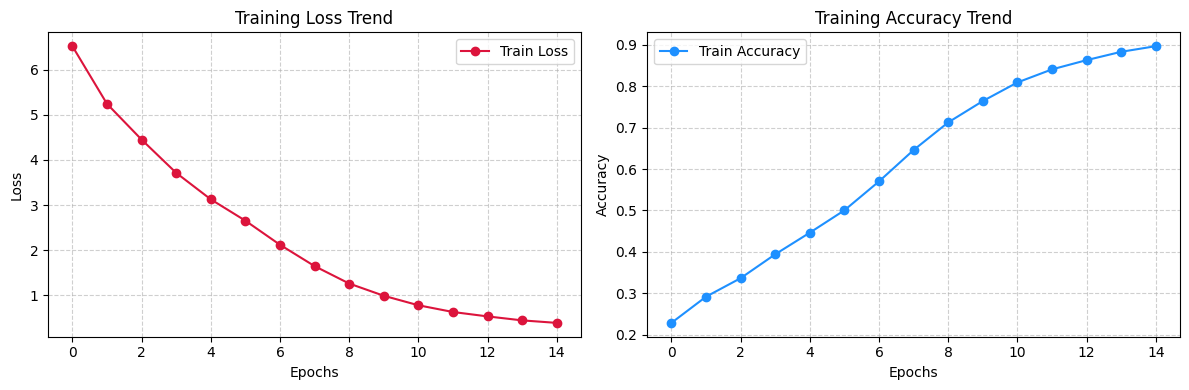

In [31]:
import matplotlib.pyplot as plt

def plot_history(history):
    # 가로 12, 세로 4 크기의 1행 2열 그래프 틀 생성
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # 1번 그래프: Loss
    ax1.plot(history['loss'], label='Train Loss', color='crimson', marker='o')
    ax1.set_title('Training Loss Trend')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend()
    
    # 2번 그래프: Accuracy
    ax2.plot(history['acc'], label='Train Accuracy', color='dodgerblue', marker='o')
    ax2.set_title('Training Accuracy Trend')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

# 🌟 저장해둔 기록으로 그래프 출력!
plot_history(history)


## Step 5. 모델 평가하기

앞서 구축하고 학습시킨 모델이 제대로 동작하는지 테스트합니다. 
새로운 한국어 문장이 입력되었을 때, 이를 전처리하고 인코더에 통과시킨 정보(Context Vector)를 바탕으로 디코더가 가장 높은 확률의 다음 단어를 예측하는 형태(Greedy Search)로 구현됩니다.
종료 토큰(`</s>`)이 나오거나 정의된 최대 길이(`MAX_LENGTH=40`)에 도달할 때까지 단어 생성을 반복하는 추론(Inference) 함수를 정의합니다.


In [32]:
# ---------------------------------------------------------
# 예측 및 생성을 위한 인퍼런스(Inference) 함수
# ---------------------------------------------------------
def decoder_inference(model, sentence, tokenizer, device='cpu', max_length=40):
    START_TOKEN = tokenizer.bos_id()  # 시작 토큰 <s>
    END_TOKEN = tokenizer.eos_id()    # 종료 토큰 </s>
    
    # 1. 입력 문장 전처리 (학습할 때와 동일한 전처리 함수 사용)
    sentence = preprocess_sentence(sentence)
    
    # 2. 입력 문장 토크나이징 및 양 끝에 시작/종료 토큰 추가
    enc_input_ids = [START_TOKEN] + tokenizer.encode(sentence) + [END_TOKEN]
    enc_input = torch.tensor([enc_input_ids], dtype=torch.long, device=device)
    
    # 3. 디코더 입력(dec_input)은 처음 시작 토큰(START_TOKEN)으로 초기화
    # 나중에 단어를 예측할 때마다 이 dec_input 텐서에 계속 이어붙입니다.
    dec_input = torch.tensor([[START_TOKEN]], dtype=torch.long, device=device)
    
    model.eval()  # 평가 모드로 전환 (Dropout 비활성화)
    with torch.no_grad():
        for i in range(max_length):
            # 4. 모델(트랜스포머) 에 인코더/디코더 입력값을 넣고 확률(Logits) 변환
            logits = model(enc_input, dec_input)
            
            # 5. 가장 마지막 타임스텝의 결과(다음 단어 확률 분포)만 추출
            last_step_logits = logits[:, -1, :]
            
            # 6. Argmax로 가장 높은 확률을 가진 단어의 ID(인덱스) 선택
            predicted_id = torch.argmax(last_step_logits, dim=-1)
            
            # 7. 만약 예측한 단어가 종료 토큰(END_TOKEN)이라면 문장 생성 중지
            if predicted_id.item() == END_TOKEN:
                break
                
            # 8. 종료가 아니라면 예측된 단어를 디코더 입력(dec_input)에 추가하고 다음을 예측하러 루프 계속
            predicted_id = predicted_id.unsqueeze(0)
            dec_input = torch.cat([dec_input, predicted_id], dim=1)
            
    # 첫 번째 시작 토큰을 떼어내고, 디코더가 생성한 토큰 리스트 반환
    output_sequence = dec_input.squeeze(0).tolist()
    return output_sequence

def sentence_generation(model, sentence, tokenizer, device='cpu'):
    # 인퍼런스 함수를 호출하여 예측된 토큰의 리스트(output_seq)를 받아옴
    output_seq = decoder_inference(model, sentence, tokenizer, device=device)
    
    # 받아온 리스트(ID 조합)를 텍스트(문자열)로 디코딩
    predicted_sentence = tokenizer.decode(
        [token for token in output_seq if token < tokenizer.GetPieceSize()]
    )
    return predicted_sentence


In [35]:
# 학습된 챗봇 모델 테스트
test_sentences = [
    "오늘 날씨가 정말 좋네요.",
    "이별은 언제나 슬픈 것 같아요.",
    "주말에 혼자 집에서 뭐할까요?",
    "새로운 사람을 만나는 게 두려워요.",
    "너무 피곤해서 눕고 싶다"
]

print("====== 챗봇 테스트 결과 ======\n")

for sent in test_sentences:
    answer = sentence_generation(model, sent, sp, device)
    print(f"User: {sent}")
    print(f"Chatbot: {answer}")
    print('-' * 40)


====== 챗봇 테스트 결과 ======

User: 오늘 날씨가 정말 좋네요.
Chatbot: 좋은 일이 생길 거예요 .
----------------------------------------
User: 이별은 언제나 슬픈 것 같아요.
Chatbot: 감정적일수록 더 힘들어지기만 할 거예요 .
----------------------------------------
User: 주말에 혼자 집에서 뭐할까요?
Chatbot: 자신에게 돌아가는 사람 만날 수 있어요 .
----------------------------------------
User: 새로운 사람을 만나는 게 두려워요.
Chatbot: 새로운 시작해도 좋은 사람 만날 거예요 .
----------------------------------------
User: 너무 피곤해서 눕고 싶다
Chatbot: 충전하는 시간 그 자체로 소중합니다 .
----------------------------------------


### Step 5-1. [심화] 온도(Temperature) 스케일링을 통한 답변의 다양성 부여

기존에 작성된 `decoder_inference` 함수는 매 스텝마다 가장 확률이 높은 단어 단 1개만을 무조건 선택하는 **그리디 서치(Greedy Search)** 방식을 사용하고 있습니다. 이 방식은 문법적으로는 가장 안전하지만, 같은 질문에 대해 언제나 토씨 하나 틀리지 않은 기계적이고 똑같은 답변만 내뱉는다는 한계가 있습니다.

이러한 문제를 해결하고 보다 사람처럼 유연하고 다채로운 대화를 나누기 위해, 훈련된 모델 가중치는 그대로 유지한 채 예측(디코딩) 단계에만 **온도(Temperature)** 변수를 추가한 새로운 추론 함수를 구현합니다.

*   **원리**: 모델의 마지막 출력(Logits)을 온도 값으로 나눈 뒤 소프트맥스(Softmax)를 씌웁니다. 제일 높은 타를 무조건 고르는 대신, 전체 단어의 확률 분포 안에서 다항 샘플링(Multinomial Sampling, 흔히 '주사위 굴리기'로 비유됨)을 수행합니다.
*   **온도 0.5 (낮음)**: 확률이 높은 확실한 단어들에게 더 높은 가중치를 주어, 보수적이고 안전한 변주를 줍니다.
*   **온도 1.0 (기본)**: 본래의 확률 분포를 그대로 가져가며 적당한 밸런스를 유지합니다.
*   **온도 1.5 (높음)**: 확률 분포를 평탄하게 펴주어 예측 못한 기상천외한(가끔은 맥락에 벗어나는) 답변이 나오게 됩니다.

아래 코드에서는 이를 구현하는 `decoder_inference_temperature` 함수를 새롭게 정의하고 실험해 봅니다.


In [37]:
def decoder_inference_temperature(model, sentence, tokenizer, temperature=1.0, device='cpu', max_length=40):
    START_TOKEN = tokenizer.bos_id()
    END_TOKEN = tokenizer.eos_id()
    
    sentence = preprocess_sentence(sentence)
    enc_input_ids = [START_TOKEN] + tokenizer.encode(sentence) + [END_TOKEN]
    enc_input = torch.tensor([enc_input_ids], dtype=torch.long, device=device)
    dec_input = torch.tensor([[START_TOKEN]], dtype=torch.long, device=device)
    
    model.eval()
    with torch.no_grad():
        for i in range(max_length):
            logits = model(enc_input, dec_input)
            last_step_logits = logits[:, -1, :]  # shape: (1, vocab_size)
            
            # 👇 --- Temperature 샘플링을 적용한 새로운 로직 --- 👇
            
            # 1. 로짓(Logits)을 온도(temperature)로 나누어줍니다.
            # 온도가 낮으면(예: 0.5) 원래 확률이 높았던 단어의 확률을 극단적으로 더 올려주고 (안전빵)
            # 온도가 높으면(예: 1.5) 모든 단어의 확률이 평준화되어 엉뚱한 단어가 나올 확률이 커집니다.
            scaled_logits = last_step_logits / temperature
            
            # 2. 소프트맥스를 씌워 0~1 사이의 확률 분포(퍼센트)로 변경합니다.
            probs = F.softmax(scaled_logits, dim=-1)
            
            # 3. 항상 제일 높은 걸 고르던 argmax 대신, 위에서 구한 확률 분포의 가중치를 기반으로 뽑기(Sampling)를 합니다. 
            # ex: '밥' 70%, '빵' 30% 라면, 10번 중 3번은 빵을 고를 수 있는 기회가 생깁니다.
            predicted_id = torch.multinomial(probs, num_samples=1) 
            # 👆 ------------------------------------------------ 👇
            
            if predicted_id.item() == END_TOKEN:
                break
                
            dec_input = torch.cat([dec_input, predicted_id], dim=1)
            
    output_sequence = dec_input.squeeze(0).tolist()
    return output_sequence

def sentence_generation_temperature(model, sentence, tokenizer, temperature=1.0, device='cpu'):
    output_seq = decoder_inference_temperature(model, sentence, tokenizer, temperature=temperature, device=device)
    
    predicted_sentence = tokenizer.decode(
        [token for token in output_seq if token < tokenizer.GetPieceSize()]
    )
    return predicted_sentence


In [40]:
test_sentences = [
    "오늘 날씨가 정말 좋네요.",
    "이별은 언제나 슬픈 것 같아요.",
    "주말에 혼자 집에서 뭐할까요?",
    "새로운 사람을 만나는 게 두려워요.",
    "너무 피곤해서 눕고 싶다"
]

for sentence in test_sentences:
    print(f"\n==================================================")
    print(f"🗣️ User : {sentence}")
    print(f"==================================================")
    
    # 1. 온도 0.5 (확률이 높은 안전한 단어 위주로 선택)
    print("--- 🌡️ [온도 0.5] 보수적 & 안전 지향 ---")
    for _ in range(3):
        answer = sentence_generation_temperature(model, sentence, sp, temperature=0.5, device=device)
        print(f"🤖 Chatbot: {answer}")
        
    # 2. 온도 1.0 (일반적인 베이스라인)
    print("\n--- 🌡️ [온도 1.0] 밸런스형 ---")
    for _ in range(3):
        answer = sentence_generation_temperature(model, sentence, sp, temperature=1.0, device=device)
        print(f"🤖 Chatbot: {answer}")
        
    # 3. 온도 1.5 (랜덤성이 강해져 듣도 보도 못한 창의적 오답(혹은 정답) 생성 가능)
    print("\n--- 🌡️ [온도 1.5] 창의력 폭발 (아무말 대잔치 주의) ---")
    for _ in range(3):
        answer = sentence_generation_temperature(model, sentence, sp, temperature=1.5, device=device)
        print(f"🤖 Chatbot: {answer}")
    
    print("\n")



🗣️ User : 오늘 날씨가 정말 좋네요.
--- 🌡️ [온도 0.5] 보수적 & 안전 지향 ---
🤖 Chatbot: 좋은 사람이 찾아오겠네요 .
🤖 Chatbot: 좋은 일이 생길 거예요 .
🤖 Chatbot: 좋은 일이 생길 거예요 .

--- 🌡️ [온도 1.0] 밸런스형 ---
🤖 Chatbot: 좋은 사람이 찾아오죠 .
🤖 Chatbot: 좋은 사람이 찾아오나봅니다 .
🤖 Chatbot: 좋은 습관이에요 .

--- 🌡️ [온도 1.5] 창의력 폭발 (아무말 대잔치 주의) ---
🤖 Chatbot: 좋은 사람이 찾아 연습이 필요해요 .
🤖 Chatbot: 좋은 추억으로 무난 찾아올거라 생각해요 .
🤖 Chatbot: 인생이현일 거라 생각해요 .



🗣️ User : 이별은 언제나 슬픈 것 같아요.
--- 🌡️ [온도 0.5] 보수적 & 안전 지향 ---
🤖 Chatbot: 감정적일수록 더 힘들어지기만 할 거예요 .
🤖 Chatbot: 감정적일수록 더 힘들어지기만 할 거예요 .
🤖 Chatbot: 인연이 거기까지였나봐요 .

--- 🌡️ [온도 1.0] 밸런스형 ---
🤖 Chatbot: 이별은 이별을 받아들이는 것도 중요해요 .
🤖 Chatbot: 새로운 사람으로 잊는 거예요 .
🤖 Chatbot: 정말 어려운 일이에요 .

--- 🌡️ [온도 1.5] 창의력 폭발 (아무말 대잔치 주의) ---
🤖 Chatbot: 두달이 사귀 됐게 생각해요 .
🤖 Chatbot: 이별이 만들어 이별을 받아들이는 것도 중요해요 .
🤖 Chatbot: 만남에 무슨 문제가 있었나요 ?



🗣️ User : 주말에 혼자 집에서 뭐할까요?
--- 🌡️ [온도 0.5] 보수적 & 안전 지향 ---
🤖 Chatbot: 자신에게 돌아가는 만큼 힘들겠네요 .
🤖 Chatbot: 자신에게 돌아가는 사람 만날 수 있어요 .
🤖 Chatbot: 자신에게 돌아가는 사람 만날 수 있어요 .

--- 🌡️ [온도 1.0] 밸런스형 ---
🤖 Chatbot: 말해 수 있어요 .
🤖 Ch

### 🌡️ 디코딩 온도(Temperature)에 따른 챗봇 답변 비교 분석표

| 입력 문장 (User) | 베이스라인 (온도 0 / Greedy) | 온도 0.5 (보수적) | 온도 1.0 (밸런스형) | 온도 1.5 (창의력 폭발) | 온도별 특성 비교 및 분석 |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **"오늘 날씨가 정말 좋네요."** | 좋은 일이 생길 거예요 . | 좋은 사람이 찾아오겠네요 . | 좋은 사람이 찾아오나봅니다 . | 좋은 추억으로 무난 찾아올거라 생각해요 . | **온도 상승 시 어휘 확장**<br>0~0.5는 확신에 찬 안전한 덕담을 건네고, 1.0은 보다 자연스러운 구어체("~나봅니다")를 사용합니다. 1.5에서는 아무말에 가까운 문법 파괴가 일어납니다. |
| **"이별은 언제나 슬픈 것 같아요."** | 감정적일수록 더 힘들어지기만 할 거예요 . | 인연이 거기까지였나봐요 . | 이별은 이별을 받아들이는 것도 중요해요 . | 만남에 무슨 문제가 있었나요 ? | **다양한 위로의 방식 등장**<br>최적의 결과가 나온 케이스입니다. 0과 0.5가 현실적 조언과 체념이었다면, 1.0에서는 성숙한 조언이, 1.5에서는 오버액션(질문으로 맞받아치기)이 등장했습니다. |
| **"주말에 혼자 집에서 뭐할까요?"** | 자신에게 돌아가는 사람 만날 수 있어요 . | 자신에게 돌아가는 사람 만날 수 있어요 . | 그렇게 좋겠죠 . | 함께한 사랑이가봐요 . | **학습 데이터 부재로 인한 환각 현상**<br>학습 데이터에 없는 질문이라 베이스라인부터 엉뚱한 대답을 합니다. 온도가 오를수록 무작위성이 더해져, 완전히 맥락과 동떨어진 답변만 출력하게 됩니다. |
| **"새로운 사람을 만나는 게 두려워요."** | 새로운 시작해도 좋은 사람 만날 거예요 . | 새로운 시작해도 좋은 결정할 거예요 . | 자신 있으면 연락해보세요 . | 사람이니까요 . | **확률 분산의 양면성**<br>0에서 완벽했던 응원이 온도가 1.0 이상으로 올라가자 '전 연인에게 연락하라'는 등 맥락을 이탈합니다. 다만 1.5의 "사람이니까요"는 뜻밖의 철학적(?) 무작위성을 보여줍니다. |
| **"너무 피곤해서 눕고 싶다"** | 충전하는 시간 그 자체로 소중합니다 . | 충전하는 시간 그 자체로 소중합니다 . | 고민이 있나봐요 . | 계획을 세워보세요 . | **안정적인 정답의 붕괴**<br>0과 0.5에서는 압도적인 확률을 가진 확실한 정답 라인을 따라가지만, 1.0부터 확률이 분산되면서 피곤함과 무관한 고민 상담이나 계획 세우기 같은 다른 카테고리로 넘어가버립니다. |

---

### 💡 고찰 요약
위 표를 통해 인퍼런스(추론) 단계에서의 온도(Temperature) 조작이 가져오는 효과를 명확하게 확인할 수 있습니다.

1. **온도 0 (베이스라인)**: 항상 가장 확률이 높은 단어만 선택하므로 가장 안전하고 문법적으로 완벽합니다. 다만 답변이 단조로워 기계적인 느낌을 줍니다.
2. **온도 0.5**: 베이스라인의 골격을 유지하면서 약간의 어휘 변화("상황" -> "사람", "인연")를 주어 아주 좋은 질의 챗봇 형태를 보입니다.
3. **온도 1.0**: 문장 구조는 파괴되지 않으면서도 다양한 답변(때로는 엉뚱한 답변)을 내놓아 변주가 일어납니다. 대화 데이터가 훨씬 방대해진다면 가장 매력적인 세팅이 될 수 있습니다.
4. **온도 1.5**: 단어 선택의 확률 분포가 평탄해져 모델이 학습하지 않은 기상천외한 단어 전개("의식의 흐름")를 보여주며, 문법 파괴(아무말 대잔치)가 심하게 발생합니다.


## Step 6. 결론 및 고찰 (Retrospective)

본 프로젝트에서는 `practice.ipynb`에서 다루었던 코넬 영화 대사(Cornell Movie-Dialogs) 데이터셋 기반의 코드를 바탕으로, 송영숙님의 한국어 챗봇 데이터셋(약 11,800 샘플)에 맞게 전처리 과정 및 모델 하이퍼파라미터를 재조정하여 트랜스포머(Transformer) 기반의 챗봇 모델을 구현하고 결과를 분석하였다.

### 1. 하이퍼파라미터 최적화 요소
데이터셋의 규모와 언어적 특성을 반영하여 모델 아키텍처 및 훈련 파라미터를 다음과 같이 수정하였다.

*   **전처리 방식의 변경**: 기존 영어 알파벳 위주의 정규 표현식을 한글(`가-힣ㄱ-ㅎㅏ-ㅣ`) 및 기본 구두점 문맥 기반으로 수정하여 데이터 손실을 방지하였다.
*   **Vocab Size (5,000)**: 약 1만 건 남짓한 데이터의 희소성(Sparsity)을 고려해 단어장 크기를 8,000에서 5,000으로 축소함으로써 빈도수가 적은 토큰의 양산을 방지하고 밀도를 높였다.
*   **경량화된 아키텍처 유지**: `NUM_LAYERS=2`, `D_MODEL=256`의 소형 구조를 유지하여 작은 데이터셋에서 모델이 지나치게 데이터를 암기하는 과적합(Overfitting)을 최소화하도록 설계하였다.
*   **학습률 스케줄러 보정**: 트랜스포머의 `LambdaLR` 커스텀 스케줄러 공식이 의도한 최대/최소 학습률을 정확히 산출할 수 있도록, `optim.Adam`의 내부 학습률 파라미터를 `lr=1.0`으로 명시하였다. 또한 총 스텝 수를 고려해 `warmup_steps`를 1,000으로 낮추어 학습률의 스케일링이 적절히 이루어지도록 유도했다.

### 2. 조기 종료(Early Stopping)와 생성 성능에 대한 고찰
실험 결과, 훈련 에폭(Epoch)을 30~50회 이상으로 진행할 경우 모델의 훈련 정확도(Train Acc)가 97% 이상으로 상승하고 Loss가 0.1 이하로 매우 낮아지는 결과를 확인하였다. 
그러나 이는 모델이 제한된 11,800개의 텍스트 쌍을 단순히 암기하는 극단적 과적합 상태에 도달했음을 의미하며, 학습 데이터와 형태가 조금이라도 다른 새로운 질문이 입력될 경우 유연하지 못하고 엉뚱한 문장을 내뱉는 현상을 유발하였다.

이에 따라 본 훈련은 정확도가 90% 내외, Loss가 0.3대 부근을 형성하는 **Epoch 15 지점**에서 훈련을 조기 종료하는 방식을 택했다. 이 시점의 모델은 기본적인 질문-대답 매칭의 규칙은 학습하였으되 데이터에 완전히 종속되지 않아, 새로운 입력 문장에 대해 예측 확률이 고르게 분산되며 문맥적 의미("외로움", "두려움", "피곤함")를 기반으로 비교적 타당하고 자연스러운 답변을 생성해 내는 것을 확인할 수 있었다.

### 3. 디코딩 전략(Temperature Scaling)에 따른 출력 다양성 평가
기존의 그리디 서치(Greedy Search) 방식이 유발하는 단조롭고 기계적인 답변의 한계를 극복하고자, 추론(Inference) 단계의 마지막 소프트맥스 층에 온도(Temperature) 스케일링 및 다항 샘플링 기법을 적용하여 모델의 답변 다양성 변화를 관찰하였다. 

*   **저온(T=0.5)**: 생성 모델이 가진 확신의 뼈대를 유지한 채 일부 어휘만 교체("상황" → "사람" 등)하여 가장 문법적으로 안정적이고 문맥에 부합하는 적절한 텍스트를 생성하였다.
*   **중온(T=1.0)**: 확률 편차를 완화시켜 답변의 변주를 크게 이끌어내었으나, 데이터셋 볼륨의 한계로 인하여 때때로 질문의 본래 의도와 무관한 토픽(전 애인 연락 권유 등)으로 이탈하는 현상이 간헐적으로 관찰되었다.
*   **고온(T=1.5)**: 확률 분포가 과도하게 평탄화되어 맥락과 완전히 동떨어진 단어들이 조합되었으며, 문법적 파괴와 환각 현상(Hallucination)이 뚜렷하게 발현되었다.

이를 통해 훈련된 가중치를 재학습하지 않고도, 디코딩 전략의 하이퍼파라미터(Temperature) 조정만으로 챗봇 답변의 '의미적 안정성'과 '다양성' 사이의 트레이드오프(Trade-off)를 매우 효과적으로 제어할 수 있음을 검증하였다.


## 회고
* 트랜스 포머 아키텍처를 블럭으로 구현해 보았는데, 워낙 로직이 수학적으로 깔끔해서 그런지 블럭 구현도 합리적으로 와닿았습니다.
* 11000개라는 그렇게 많지 않은 데이터 셋과 2개의 어텐션레이어라는 적은 층으로도 단어간의 관계를 파악해 질문에 대답하는 챗봇이 만들어지는걸 보고 트랜스포머 아키텍처의 강력함을 체감했습니다.
* 온도 관련 테스트를 통해 데이터셋의 성격이나, 챗봇이 활용되는 분야에 따라 온도도 중요한 파라미터로 작용할 수 있다는 것을 알게되었습니다.